# Before going into my code, make sure to do the following below:
1. click view -> Enable full width notebook. Not doing so will mae the table look really weird in your screen, especially for those with small computer screen. You can then zoom out and it should display all column.

In [ ]:
!mamba install pandas 
!mamba install seaborn # really weird, but I guess this is how to install these in jupyter

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.3896999999284745 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, #, really, weird,, but, I, guess, this, is, how, to, install, these, in, jupyter
Channels: emscripten-forge-4x, conda-forge

Solving environment...


missing package name

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re # importing essential stuff.

# Start of data cleaning

In [8]:
df = pd.read_csv('data_mmda_traffic_spatial.csv') # loading csv file

In [9]:
df = df.drop(columns=["Tweet","Source"]) # dropping the unnecessary columns
df = df[df['High_Accuracy'] == 1].drop(columns=['High_Accuracy']) # dropping low accuracy entries
df = df.dropna(subset=['Time', 'City']) # dropping null rows as time and city are needed in my data

In [11]:
df['Month'] = pd.to_datetime(df['Date']).dt.strftime('%B %Y')  # added a column only retaining year and month

In [12]:
df['Time_parsed'] = pd.to_datetime(df['Time'], format='%I:%M %p', errors='coerce')
df['Hour'] = df['Time_parsed'].dt.hour.astype('Int64')  # added a column with the time in hours only
df = df.drop(columns=['Time_parsed']) # dropped column as hour is already extracted

In [13]:
df['City'] = df['City'].str.replace('ParaÃ±aque', 'Parañaque', regex=False) # fixing data entry
df['City'] = df['City'].str.replace(' City', '', regex=False) # making values consistent

In [14]:
valid_dirs = ['NB', 'SB', 'EB', 'WB']
df['Direction'] = df['Direction'].where(df['Direction'].isin(valid_dirs), other=None) # removing unnecessary data

In [15]:
df['Lanes_Blocked'] = df['Lanes_Blocked'].astype('Int64') # changing data type to int

In [16]:
# dealing with nulls
df['Lanes_Blocked'] = df['Lanes_Blocked'].fillna(1).astype('Int64')
df['Direction'] = df['Direction'].fillna('Unknown')
df['Involved'] = df['Involved'].fillna('Unknown')

# ONLY run code below to check for nulls

In [19]:
df.isnull().sum()

Date              0
Time              0
City              0
Location          0
Latitude          0
Longitude         0
Direction         0
Type             42
Lanes_Blocked     0
Involved          0
Month             0
Hour             92
dtype: int64

In [20]:
# adding a new clean "type" column
def categorize_type(val):
    if pd.isna(val):
        return None
    v = str(val).upper().strip()

    if re.search(
            r'VEH[A-Z]*\s*ACCIDENT|VEHICULAR ACIDENT|VEHICULAR ACCIEDNT|VEHICULAR ACCCIDENT|VEHCICULAR|VEHICHULAR|VEHICULAR|VEHICUKAR|VEHICUALR|VEHICUKLAR',
            v):
        return 'Vehicular Accident'
    if re.search(r'MUL[A-Z]*\s*COL+ISION|MULTIPLE COLL', v):
        return 'Multiple Collision'
    if v.startswith('SELF ACCIDENT') or 'SELF ACCIDENT' in v:
        return 'Self Accident'
    if re.search(r'VEHIC[A-Z]* (ON )?FIRE|VEHICLE ON FIRE', v):
        return 'Vehicular Fire'
    if v.startswith('STALLED') or 'STALLED' in v:
        return 'Stalled Vehicle'
    if re.search(
            r'DPWH|MAYNILAD|MERALCO|MMDA TEC|ROAD PATCH|REBLOCKING|RE-BLOCKING|RE BLOCKING|DECLOGGING|ROAD REPAIR|ASPHAL|LANE MARK|MANHOLE REPAIR|FLOOD CONTROL|DRAINAGE REPAIR|CEMENT POUR|SQUARING|ROAD REHAB|BEAUTIFICATION|TARPAULIN|WALL CLEAN|WALL PAINT|BARRIER MAINT|FOOTBRIDGE|MMDA MPCG|ONGOING.*REPAIR|ONGOING.*ROAD',
            v): # this has to be the most tiring clean of my life T-T
        return 'Road Works'
    if re.search(r'ROAD CLOSURE|TEMPORARY.*CLOSURE', v):
        return 'Road Closure'
    if re.search(r'RALLY|MOTORCADE|PARADE|CARAVAN|MARCH|PROCESSION|MOTORCAMP', v):
        return 'Public Event'
    if re.search(r'SHOOTING|STABBING|HIT AND RUN|SUSPICIOUS|DEAD PERSON', v):
        return 'Incident'
    if re.search(
            r'OIL SPILL|FALLEN TREE|TREE HAS FALLEN|OPEN MANHOLE|DRAINAGE HOLE|MISALIGNED|FALLEN WALL|FALLEN BOARD', v):
        return 'Hazard'
    return 'Other'

df['Type_Category'] = df['Type'].apply(categorize_type)

# Run code below to check if everything is in order

In [21]:
print(df.loc[0:50].to_string())

          Date      Time         City                     Location   Latitude   Longitude Direction                                         Type  Lanes_Blocked                       Involved        Month  Hour       Type_Category
0   2018-08-20   7:55 AM        Pasig              ORTIGAS EMERALD  14.586343  121.061481        EB                           VEHICULAR ACCIDENT              1                    TAXI AND MC  August 2018     7  Vehicular Accident
1   2018-08-20   8:42 AM  Mandaluyong                  EDSA GUADIX  14.589432  121.057243        NB       STALLED L300 DUE TO MECHANICAL PROBLEM              1                           L300  August 2018     8     Stalled Vehicle
2   2018-08-20   9:13 AM       Makati                EDSA ROCKWELL  14.559818  121.040737        SB                           VEHICULAR ACCIDENT              1                   SUV AND L300  August 2018     9  Vehicular Accident
3   2018-08-20   8:42 AM  Mandaluyong                  EDSA GUADIX  14.589432  1

# End of data cleaning

# Start of EDA

In [23]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 16291 entries, 0 to 17311
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           16291 non-null  str    
 1   Time           16291 non-null  str    
 2   City           16291 non-null  str    
 3   Location       16291 non-null  str    
 4   Latitude       16291 non-null  float64
 5   Longitude      16291 non-null  float64
 6   Direction      16291 non-null  str    
 7   Type           16249 non-null  str    
 8   Lanes_Blocked  16291 non-null  Int64  
 9   Involved       16291 non-null  str    
 10  Month          16291 non-null  str    
 11  Hour           16199 non-null  Int64  
 12  Type_Category  16249 non-null  str    
dtypes: Int64(2), float64(2), str(9)
memory usage: 1.6 MB
None


In [25]:
print(df.describe())

           Latitude     Longitude  Lanes_Blocked       Hour
count  16291.000000  16291.000000        16291.0    16199.0
mean      14.605385    121.051831       1.093242  12.274338
std        0.039885      0.022572       0.296218   5.411176
min       14.499519    120.959766            1.0        0.0
25%       14.577625    121.044944            1.0        8.0
50%       14.601700    121.053801            1.0       12.0
75%       14.632910    121.069619            1.0       16.0
max       14.735495    121.104893            6.0       23.0


In [26]:
print(df.value_counts())

Date        Time      City         Location                      Latitude   Longitude   Direction  Type                                         Lanes_Blocked  Involved             Month          Hour  Type_Category     
2019-10-30  8:54 PM   Mandaluyong  EDSA PIONEER                  14.572454  121.047299  NB         VEHICULAR ACCIDENT                           1              BUS AND MOTORCYCLE   October 2019   20    Vehicular Accident    11
2018-10-25  4:35 AM   Pasig        C5 ORTIGAS FLYOVER            14.589706  121.079945  SB         VEHICULAR ACCIDENT                           1              TRUCK                October 2018   4     Vehicular Accident     8
2019-03-26  3:31 PM   Quezon       EDSA CONNECTICUT              14.601700  121.059252  SB         SHOOTING INCIDENT                            1              MOTORCYCLE           March 2019     15    Incident               8
2018-12-11  5:23 AM   Makati       C5 PALAR                      14.533113  121.057720  SB         STA

In [27]:
df['Hour'].value_counts().sort_index() # incidents per hour

Hour
0      238
1      118
2       50
3       62
4      275
5      562
6      956
7     1300
8     1219
9     1125
10    1083
11     971
12     848
13     526
14     805
15    1046
16     974
17     729
18     778
19     713
20     641
21     381
22     406
23     393
Name: count, dtype: Int64

In [28]:
print(df['City'].value_counts()) # incidents per city

City
Quezon         8185
Mandaluyong    2895
Makati         2404
Pasig          1667
Pasay           397
Manila          308
San Juan        116
Marikina        112
Parañaque        94
Kalookan         70
Taguig           31
Valenzuela        5
Malabon           4
Navotas           3
Name: count, dtype: int64


In [29]:
print(df['Month'].value_counts()) # incidents per month

Month
March 2019        1026
October 2018       916
January 2019       893
July 2019          890
August 2019        877
October 2019       839
February 2019      834
September 2019     823
April 2019         808
May 2019           797
June 2019          787
January 2020       774
November 2018      767
February 2020      758
November 2019      739
September 2018     702
December 2018      664
December 2019      608
October 2020       406
March 2020         289
November 2020      271
August 2018        247
September 2020     225
December 2020      201
May 2020            73
June 2020           67
April 2020          10
Name: count, dtype: int64


In [30]:
print(df['Type_Category'].value_counts())

Type_Category
Vehicular Accident    11205
Stalled Vehicle        3748
Multiple Collision      593
Road Works              254
Self Accident           250
Public Event             95
Incident                 59
Other                    29
Road Closure              9
Hazard                    7
Name: count, dtype: int64


In [31]:
print(df.groupby('Type_Category')['Lanes_Blocked'].mean())

Type_Category
Hazard                1.285714
Incident              1.084746
Multiple Collision    1.468803
Other                 1.034483
Public Event          1.252632
Road Closure          1.333333
Road Works             1.03937
Self Accident              1.0
Stalled Vehicle       1.000267
Vehicular Accident    1.106381
Name: Lanes_Blocked, dtype: Float64


In [32]:
print(df['Direction'].value_counts())

Direction
NB         6333
SB         5728
EB         1822
WB         1632
Unknown     776
Name: count, dtype: int64


# End of EDA

# Start of visualization

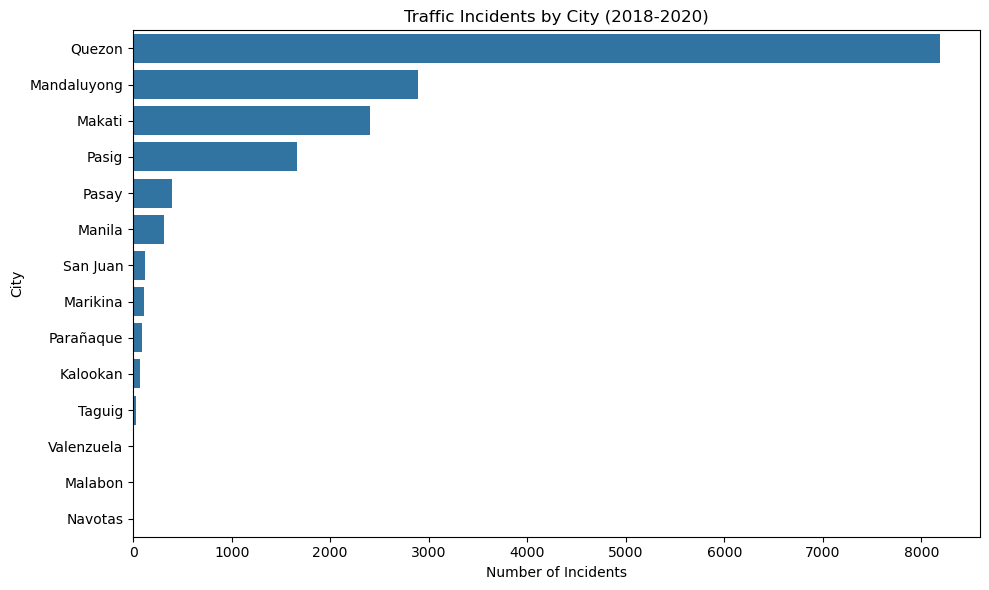

In [33]:
city_counts = df['City'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Traffic Incidents by City (2018-2020)')
plt.xlabel('Number of Incidents')
plt.ylabel('City')
plt.tight_layout()
plt.show()

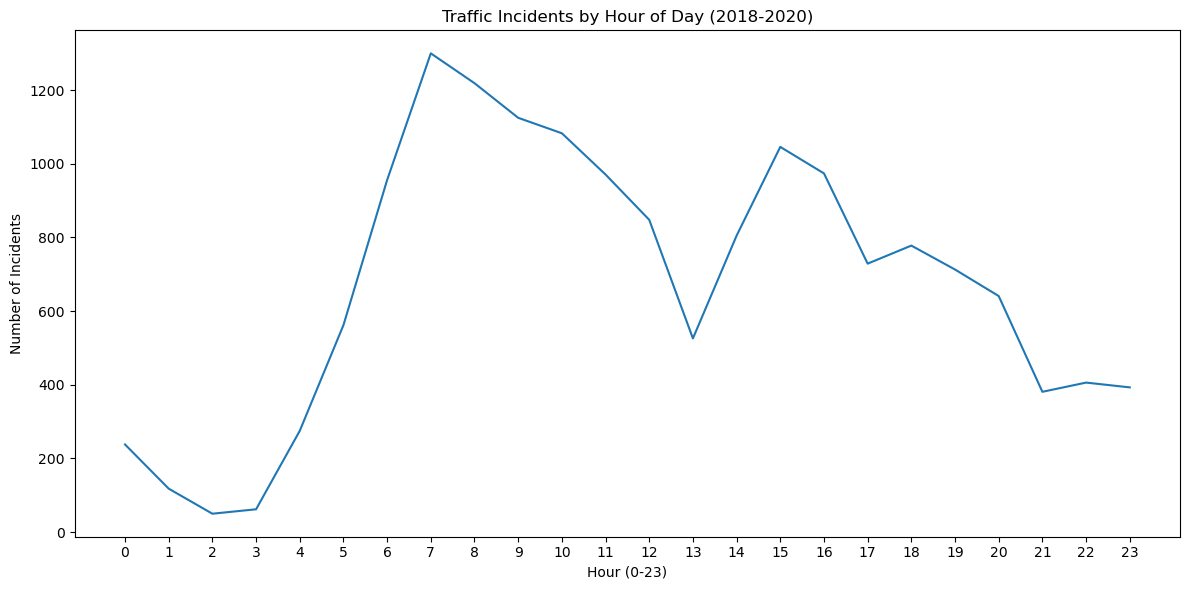

In [34]:
hour_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=hour_counts.index, y=hour_counts.values)
plt.title('Traffic Incidents by Hour of Day (2018-2020)')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Incidents')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

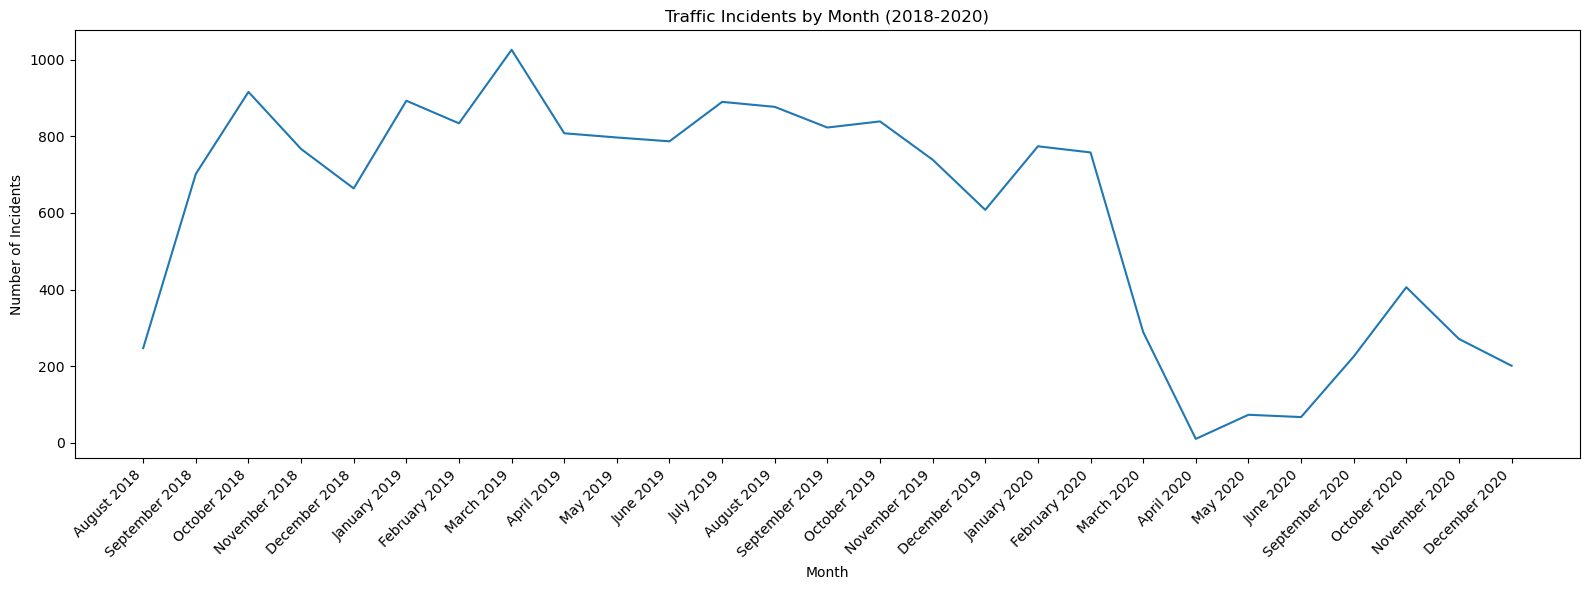

In [35]:
month_counts = df.groupby('Month').size().reset_index(name='Count')
month_counts['Month'] = pd.to_datetime(month_counts['Month'], format='%B %Y')
month_counts = month_counts.sort_values('Month')
month_counts['Month'] = month_counts['Month'].dt.strftime('%B %Y')

plt.figure(figsize=(16, 6))
sns.lineplot(x=month_counts['Month'], y=month_counts['Count'])
plt.title('Traffic Incidents by Month (2018-2020)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

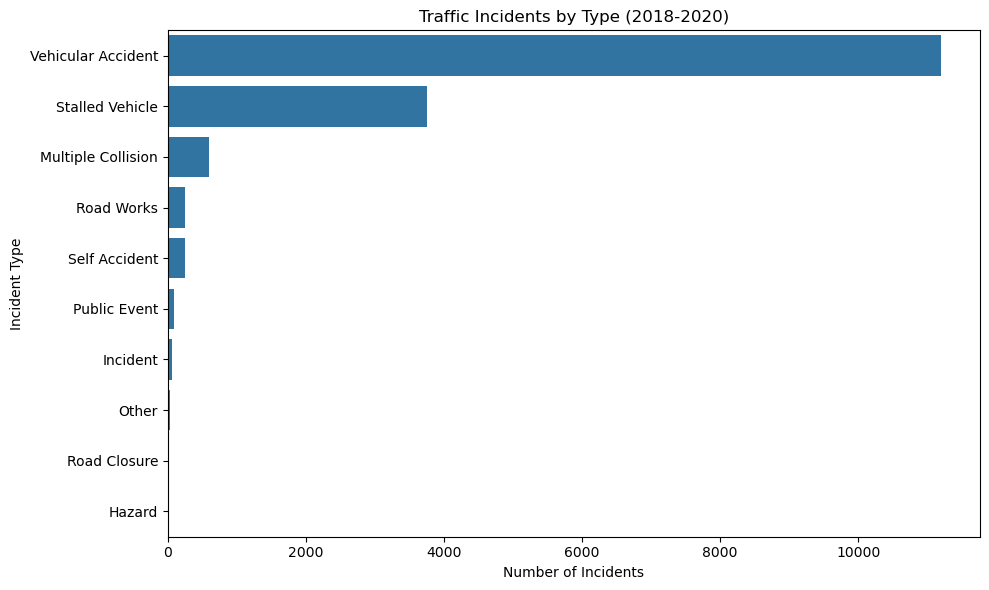

In [36]:
type_counts = df['Type_Category'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=type_counts.values, y=type_counts.index)
plt.title('Traffic Incidents by Type (2018-2020)')
plt.xlabel('Number of Incidents')
plt.ylabel('Incident Type')
plt.tight_layout()
plt.show()

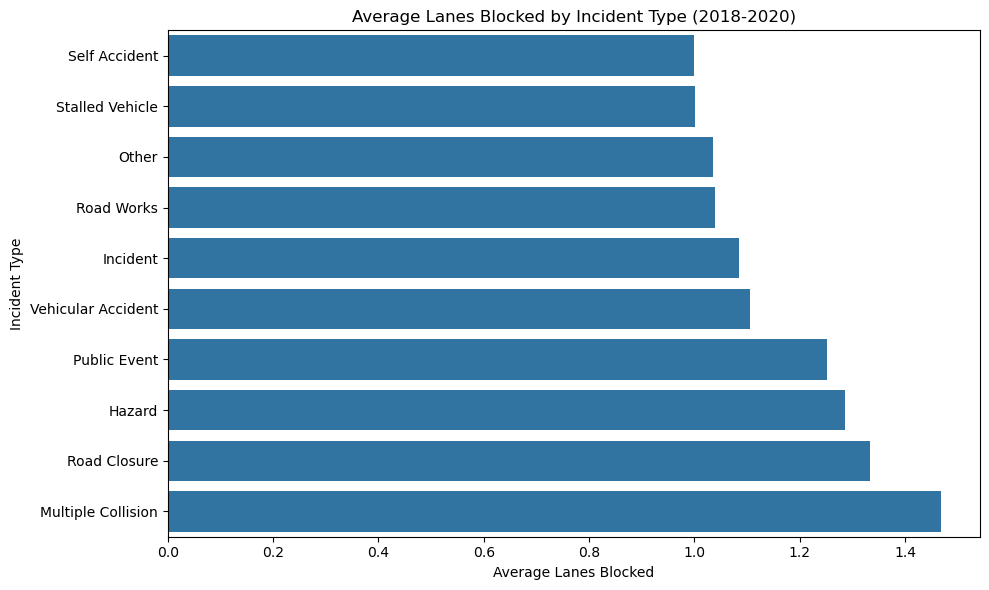

In [37]:
lanes_by_type = df.groupby('Type_Category')['Lanes_Blocked'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=lanes_by_type.values, y=lanes_by_type.index)
plt.title('Average Lanes Blocked by Incident Type (2018-2020)')
plt.xlabel('Average Lanes Blocked')
plt.ylabel('Incident Type')
plt.tight_layout()
plt.show()

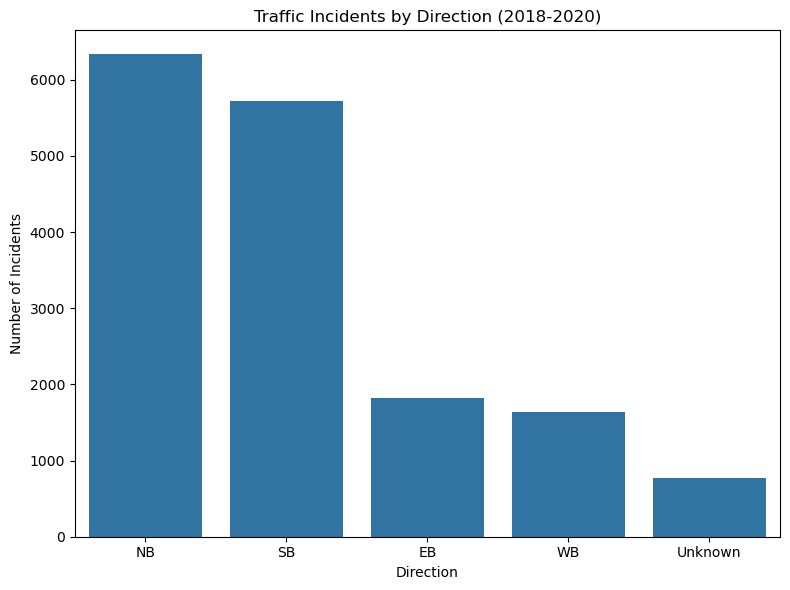

In [38]:
dir_counts = df['Direction'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=dir_counts.index, y=dir_counts.values)
plt.title('Traffic Incidents by Direction (2018-2020)')
plt.xlabel('Direction')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

# End of visualization

# Start of cross-analysis

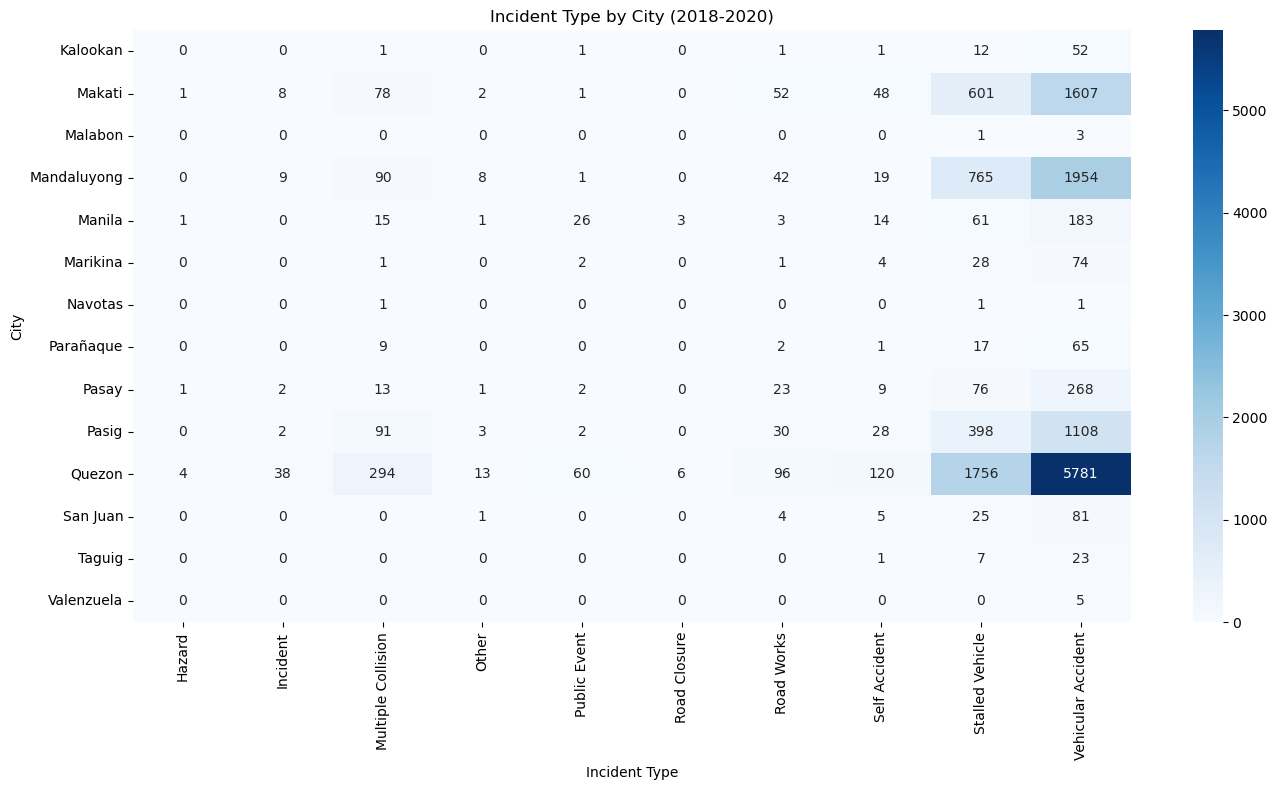

In [39]:
type_city = df.groupby(['City', 'Type_Category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(type_city, annot=True, fmt='d', cmap='Blues')
plt.title('Incident Type by City (2018-2020)')
plt.xlabel('Incident Type')
plt.ylabel('City')
plt.tight_layout()
plt.show()

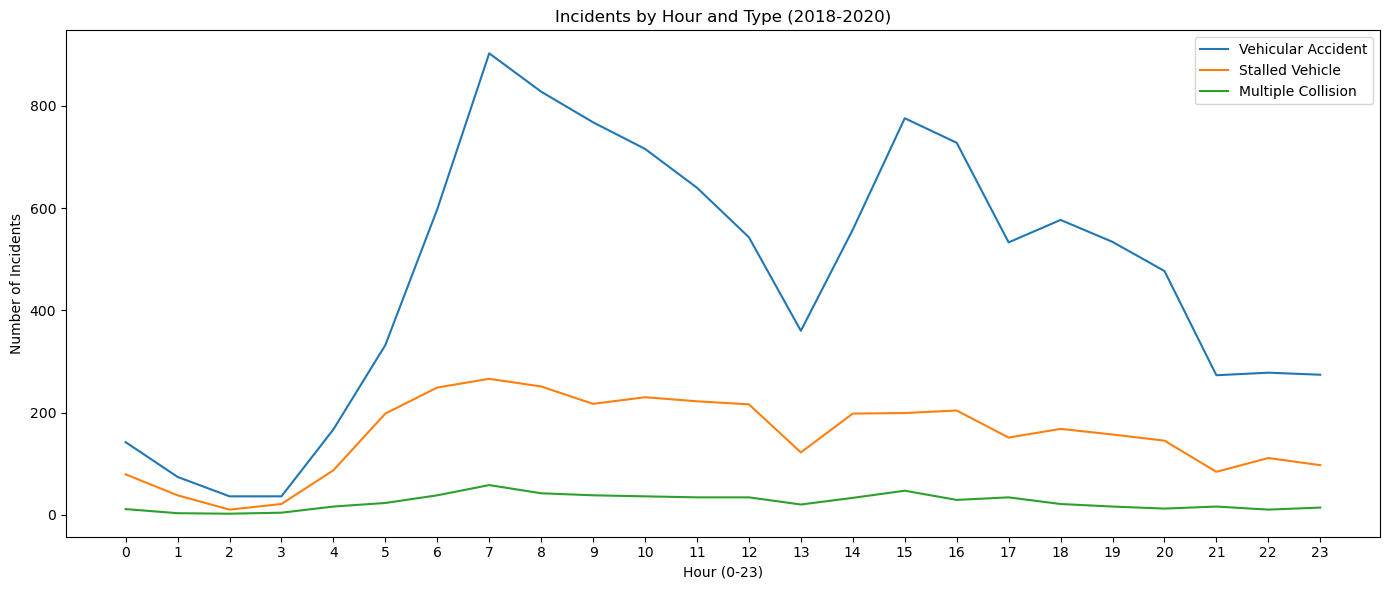

In [40]:
hour_type = df.groupby(['Hour', 'Type_Category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
for col in ['Vehicular Accident', 'Stalled Vehicle', 'Multiple Collision']:
    sns.lineplot(x=hour_type.index, y=hour_type[col], label=col)
plt.title('Incidents by Hour and Type (2018-2020)')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Incidents')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


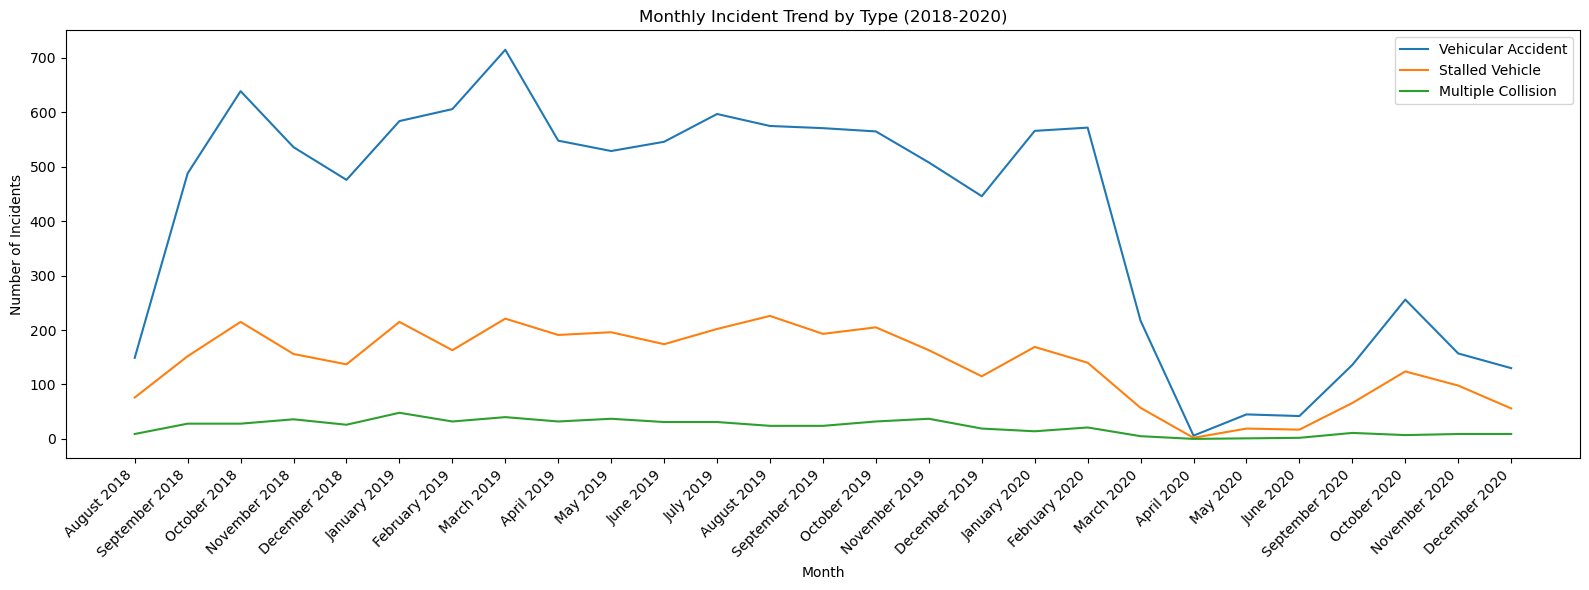

In [41]:
month_type = df.groupby(['Month', 'Type_Category']).size().unstack(fill_value=0)
month_type.index = pd.to_datetime(month_type.index, format='%B %Y')
month_type = month_type.sort_index()
month_type.index = month_type.index.strftime('%B %Y')

plt.figure(figsize=(16, 6))
for col in ['Vehicular Accident', 'Stalled Vehicle', 'Multiple Collision']:
    sns.lineplot(x=month_type.index, y=month_type[col], label=col)
plt.title('Monthly Incident Trend by Type (2018-2020)')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# End of cross-analysis

# Summary
1. **Quezon City is the hotspot:** Quezon City recorded 8,200+ incidents over the period — nearly 3x more than Mandaluyong, the second highest. It also leads in every incident category, driven by its size and EDSA running through it.
2. **Morning rush hour is the most dangerous time of day:** Incidents peak sharply at 7 AM (1,300 incidents) driven almost entirely by vehicular accidents. A secondary peak occurs at 3 PM. The quietest period is 2–3 AM with under 65 incidents combined.
3. **COVID-19 lockdown caused a near-total halt in incidents:** Monthly incidents averaged 800–1,000 from 2018 through early 2020. In April 2020, this collapsed to near zero following the ECQ. Incidents partially recovered through the rest of 2020 but never returned to pre-pandemic levels within the dataset's timeframe.
4. **Vehicular accidents dominate incident types:** Over 11,000 of ~16,000 incidents were vehicular accidents. Stalled vehicles were a distant second at ~3,800. All other categories combined account for less than 10% of total incidents.
5. **Multiple collisions block the most lanes despite being rare:**  Though multiple collisions represent a small fraction of incidents, they average 1.45 lanes blocked per incident — the highest of any category. This makes them disproportionately disruptive relative to their frequency.
6. **North and Southbound roads bear the heaviest incident load:** NB and SB incidents combined account for over 70% of all directional incidents, consistent with EDSA's north-south orientation as Metro Manila's primary arterial road.